In [5]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

EXCEL_FILE = Path("./DATA MAHASISWA MATDIS A.xlsx")
NUM_STUDENTS = 40
ATTR_NAMES = ["A_adil_bisa_dipercaya",
              "B_suka_membantu",
              "C_nyambung_ngobrol",
              "D_asyik_menarik"]

P = np.array([0.35, 0.25, 0.20, 0.20])   # Nilai beban (A-D)
RNG_SEED = 20250906
DO_KMEANS = True
K_CLUSTERS = 3

In [7]:
def load_student_names_and_values_from_excel(path: Path, required_n: int, attr_names):
    if not path.exists():
        raise FileNotFoundError(f"File Excel tidak ditemukan: {path.resolve()}")
    df = pd.read_excel(path)
    name_cols = [c for c in df.columns if "NAMA" in str(c).upper() or "NAME" in str(c).upper()]
    if not name_cols:
        raise ValueError("Excel harus mengandung kolom nama.")
    students = df[name_cols[0]].dropna().astype(str).tolist()
    students = students[:required_n]

    found_cols = []
    for attr in attr_names:
        tokens = [t.strip().upper() for t in attr.split("_")]
        match = None
        for col in df.columns:
            col_u = str(col).upper()
            if all(tok in col_u for tok in tokens if len(tok) >= 2):
                match = col
                break
        found_cols.append(match)

    if all(c is not None for c in found_cols):
        vals = df[found_cols].iloc[:required_n].to_numpy(dtype=float)
        return students, vals, found_cols
    else:
        return students, None, found_cols

def sample_C_objective(n_students, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    C_int = rng.integers(0, 11, size=(n_students, 4))
    return (C_int / 10.0).astype(float)

def print_matrix_numpy_style(arr, row_labels=None, precision=1):
    np.set_printoptions(precision=precision, suppress=True)
    print("[")
    for i in range(arr.shape[0]):
        row_str = "[" + " ".join(f"{v:.{precision}f}" for v in arr[i]) + "]"
        if row_labels:
            print(f" {row_str}   # {row_labels[i]}")
        else:
            print(f" {row_str}")
    print("]")

In [9]:
try:
    students, vals, found_cols = load_student_names_and_values_from_excel(EXCEL_FILE, NUM_STUDENTS, ATTR_NAMES)
except Exception as e:
    print("Gagal membaca Excel:", e)
    sys.exit(1)

if vals is None:
    print("Kolom A-D tidak ada, generate otomatis.")
    kelasku = sample_C_objective(NUM_STUDENTS)
else:
    kelasku = vals

print("\nMatriks kelasku (numpy-style []):")
print_matrix_numpy_style(kelasku, row_labels=students, precision=1)

Kolom A-D tidak ada, generate otomatis.

Matriks kelasku (numpy-style []):
[
 [0.9 1.0 1.0 0.2]   # MADINA HEDY ALIFANTI
 [0.7 0.3 0.3 0.2]   # MARIA DWI KURNIASIH
 [0.6 0.3 0.0 0.4]   # ADINDA PUTRI RACHMAWATI
 [0.5 0.6 0.5 1.0]   # AQUINA SYABITA
 [0.5 0.4 0.8 0.3]   # VARID PUTRA PRATAMA
 [0.2 0.1 0.6 0.4]   # GAITSA NAZWA KANSA
 [0.8 1.0 1.0 0.7]   # Mohammad Alimun Hakim
 [0.3 0.3 0.2 0.2]   # HIZKIA SAMHAN REZAYOSHI
 [0.8 0.8 0.0 0.2]   # RAVEENA AYU DESEMBER SURYOPUTRI
 [0.5 0.8 0.0 0.7]   # Yohanes Olvin Jun Sole
 [0.0 0.1 1.0 0.8]   # AISYAH AMALIA HAMID
 [0.3 0.2 0.0 0.7]   # FEBRIANI YOLANDA TESSALONIKA
 [1.0 0.3 0.5 0.3]   # AMELIA RIZQYNA PUTRI
 [0.4 0.3 0.4 0.2]   # VIA AMANDA
 [0.9 0.5 0.3 0.0]   # FANNY WIDYA CAHYANI
 [0.3 0.5 0.0 0.6]   # SITI NAIA HESTI RACHMAWATI
 [0.8 0.5 0.1 1.0]   # ALFANI NUR AZIZAH
 [0.9 1.0 0.3 0.8]   # Diah Anggraini
 [1.0 0.8 0.5 0.6]   # AHMAD KENZY FARZAQ
 [0.3 0.7 1.0 0.0]   # Angelina Nirmala Puteri Dika Praktiko
 [0.3 0.0 0.1 0.0]   # MA

In [27]:
print("\nVektor nilai beban P:", P)
scores = kelasku @ P
scores_df = pd.DataFrame(scores, index=students, columns=["score"])
scores_sorted = scores_df.sort_values("score", ascending=False)

print("\nTop 4 skor mahasiswa:")
display(scores_sorted.head(4))


Vektor nilai beban P: [0.3 0.2 0.2 0.2]

Top 4 skor mahasiswa:


,score
Mohammad Alimun Hakim,0.870
MADINA HEDY ALIFANTI,0.805
Diah Anggraini,0.785
AHMAD KENZY FARZAQ,0.770


In [29]:
cov_mat = np.cov(kelasku, rowvar=False, ddof=1)
corr_mat = np.corrcoef(kelasku, rowvar=False)

print("\nMatriks Kovarian:\n", cov_mat.round(4))
print("\nMatriks Korelasi:\n", corr_mat.round(4))


Matriks Kovarian:
 [[ 0.1  0.  -0.  -0. ]
 [ 0.   0.1  0.   0. ]
 [-0.   0.   0.1  0. ]
 [-0.   0.   0.   0.1]]

Matriks Korelasi:
 [[ 1.   0.1 -0.  -0.1]
 [ 0.1  1.   0.3  0.3]
 [-0.   0.3  1.   0.1]
 [-0.1  0.3  0.1  1. ]]


In [31]:
X_matrix = kelasku.copy()
norms = np.linalg.norm(X_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1e-9
cosine_sim = (X_matrix @ X_matrix.T) / (norms @ norms.T)
cosine_df = pd.DataFrame(cosine_sim, index=students, columns=students)

print("\nCosine similarity (8x8 kiri atas):")
print(np.round(cosine_df.values[:8, :8], 3))

pairs = []
n = len(students)
for i in range(n):
    for j in range(i+1, n):
        pairs.append((students[i], students[j], float(cosine_sim[i, j])))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("\nTop 8 pasangan mahasiswa berdasarkan cosine similarity:")
for s1, s2, sim in pairs_sorted[:8]:
    print(f"{s1} <-> {s2}: {sim:.4f}")


Cosine similarity (8x8 kiri atas):
[[1.  0.9 0.7 0.8 0.9 0.8 1.  0.9]
 [0.9 1.  0.9 0.8 0.9 0.7 0.9 0.9]
 [0.7 0.9 1.  0.8 0.6 0.5 0.8 0.9]
 [0.8 0.8 0.8 1.  0.8 0.8 0.9 0.9]
 [0.9 0.9 0.6 0.8 1.  0.9 1.  0.9]
 [0.8 0.7 0.5 0.8 0.9 1.  0.9 0.8]
 [1.  0.9 0.8 0.9 1.  0.9 1.  1. ]
 [0.9 0.9 0.9 0.9 0.9 0.8 1.  1. ]]

Top 8 pasangan mahasiswa berdasarkan cosine similarity:
VIA AMANDA <-> SELVY DWI YULITA SARI: 0.9979
CARISSA NAURA RAJWA <-> Indra Maulana R F Y: 0.9940
HIZKIA SAMHAN REZAYOSHI <-> AHMAD KENZY FARZAQ: 0.9937
Diah Anggraini <-> Rizky Faza Hafiyyan Nusantara: 0.9932
MARIA DWI KURNIASIH <-> AMELIA RIZQYNA PUTRI: 0.9924
MADINA HEDY ALIFANTI <-> NAJWA SOFIA: 0.9919
Rizky Faza Hafiyyan Nusantara <-> Indra Maulana R F Y: 0.9913
Muhammad Naufal Asruzzaman <-> ADRIAN VEDA DARMAWAN: 0.9888


In [33]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_matrix)
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_std)
explained = pca.explained_variance_ratio_

print("\nPCA (2 komponen): explained variance ratio =", explained.round(4),
      " total =", explained.sum().round(4))


PCA (2 komponen): explained variance ratio = [0.4 0.3]  total = 0.6395


C:\Users\COMPUTER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



KMeans clustering (k=3): cluster sizes:
 - cluster 0: 13 mahasiswa
   cluster 0 contoh: ['MADINA HEDY ALIFANTI', 'VARID PUTRA PRATAMA', 'Mohammad Alimun Hakim', 'AISYAH AMALIA HAMID', 'AMELIA RIZQYNA PUTRI']
 - cluster 1: 16 mahasiswa
   cluster 1 contoh: ['MARIA DWI KURNIASIH', 'ADINDA PUTRI RACHMAWATI', 'GAITSA NAZWA KANSA', 'HIZKIA SAMHAN REZAYOSHI', 'RAVEENA AYU DESEMBER SURYOPUTRI']
 - cluster 2: 11 mahasiswa
   cluster 2 contoh: ['AQUINA SYABITA', 'Yohanes Olvin Jun Sole', 'SITI NAIA HESTI RACHMAWATI', 'ALFANI NUR AZIZAH', 'Diah Anggraini']


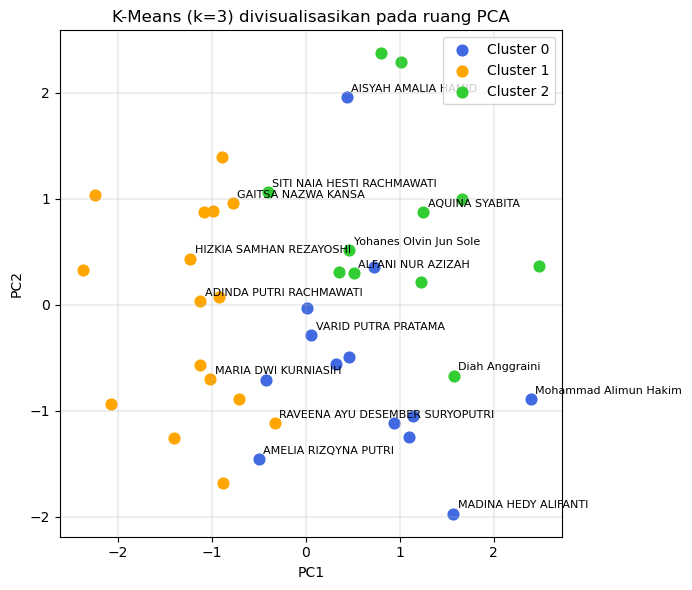

In [35]:
if DO_KMEANS:
    kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_std)

    print(f"\nKMeans clustering (k={K_CLUSTERS}): cluster sizes:")
    unique, counts = np.unique(labels, return_counts=True)
    for u, c in zip(unique, counts):
        print(f" - cluster {u}: {c} mahasiswa")
        idxs = np.where(labels == u)[0]
        contoh = [students[i] for i in idxs[:5]]
        print(f"   cluster {u} contoh: {contoh}")

    plt.figure(figsize=(7,6))
    plt.title("K-Means (k=3) divisualisasikan pada ruang PCA")
    colors = ['royalblue', 'orange', 'limegreen']
    for cluster_id in range(K_CLUSTERS):
        idxs = np.where(labels == cluster_id)
        plt.scatter(X_pca[idxs,0], X_pca[idxs,1],
                    c=colors[cluster_id], label=f"Cluster {cluster_id}", s=60)
        # tampilkan beberapa nama saja
        for j in idxs[0][:5]:
            plt.text(X_pca[j,0]+0.05, X_pca[j,1]+0.05, students[j], fontsize=8)

    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()

In [37]:
desc = pd.DataFrame(kelasku, columns=ATTR_NAMES).describe().T
print("\nRingkasan statistik kolom (mean, std, min, max):")
print(desc[["mean", "std", "min", "max"]].round(4))


Ringkasan statistik kolom (mean, std, min, max):
                         mean     std  min  max
A_adil_bisa_dipercaya  0.5425  0.3104  0.0  1.0
B_suka_membantu        0.4825  0.3169  0.0  1.0
C_nyambung_ngobrol     0.4300  0.3582  0.0  1.0
D_asyik_menarik        0.4700  0.3082  0.0  1.0


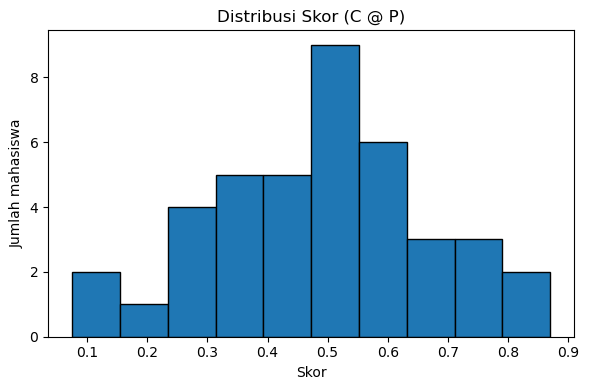

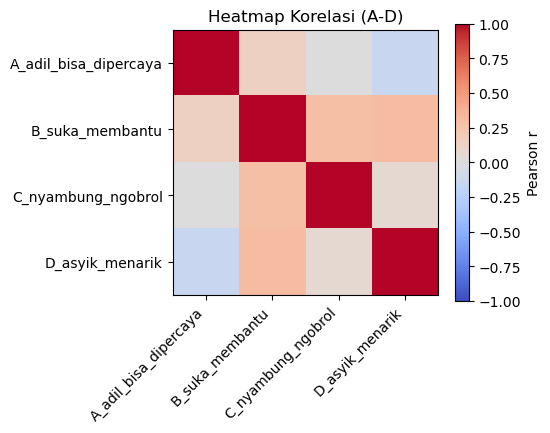

In [39]:
plt.figure(figsize=(6,4))
plt.title("Distribusi Skor (C @ P)")
plt.hist(scores, bins=10, edgecolor="black")
plt.xlabel("Skor"); plt.ylabel("Jumlah mahasiswa")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.5,4.5))
plt.title("Heatmap Korelasi (A-D)")
plt.imshow(corr_mat, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Pearson r")
plt.xticks(range(len(ATTR_NAMES)), ATTR_NAMES, rotation=45, ha="right")
plt.yticks(range(len(ATTR_NAMES)), ATTR_NAMES)
plt.tight_layout()
plt.show()